# 06 - Flux.1-schnell: Real Image Generation

Run a production text-to-image model (**Flux.1-schnell**) distilled to just 4 sampling steps.

**Runtime:** Colab L4 or A100 (T4 will use CPU offloading).

## Setup

In [ ]:
!pip -q install diffusers transformers accelerate sentencepiece

In [ ]:
import torch
from diffusers import FluxPipeline
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print("device:", DEVICE, "dtype:", DTYPE)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


device: cuda dtype: torch.bfloat16


In [ ]:
from huggingface_hub import login
from google.colab import userdata

try:
    login(token=userdata.get('HF_TOKEN'))
    print("Successfully logged into Hugging Face Hub!")
except userdata.SecretNotFoundError:
    print("HF_TOKEN secret not found. Please add it to your Colab secrets.")
except Exception as e:
    print(f"An error occurred during Hugging Face login: {e}")

Successfully logged into Hugging Face Hub!


## Load Flux.1-schnell

Load the model and enable CPU offloading to save memory.

In [ ]:
pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-schnell",
    torch_dtype=DTYPE,
)

if torch.cuda.is_available():
    pipe.enable_model_cpu_offload()       # T4-friendly

print("loaded")

model_index.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

loaded


## Generate Image

Generate an image using 4 steps and no guidance (`guidance_scale=0.0`).

  0%|          | 0/4 [00:00<?, ?it/s]

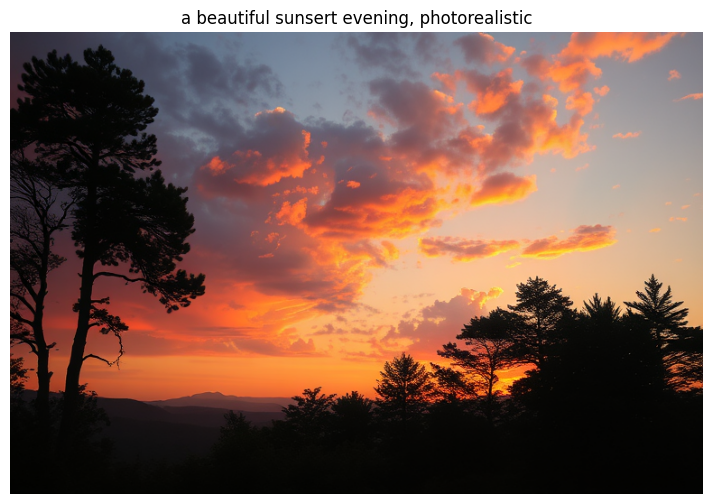

In [ ]:
prompt = "a beautiful sunset evening, photorealistic"

img = pipe(
    prompt=prompt,
    num_inference_steps=4,
    guidance_scale=0.0,
    height=512,
    width=768,
    generator=torch.Generator(DEVICE).manual_seed(0),
).images[0]

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.title(prompt)
plt.show()

## Step Count vs Quality

Compare generation quality across 1, 2, 4, and 8 steps.

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

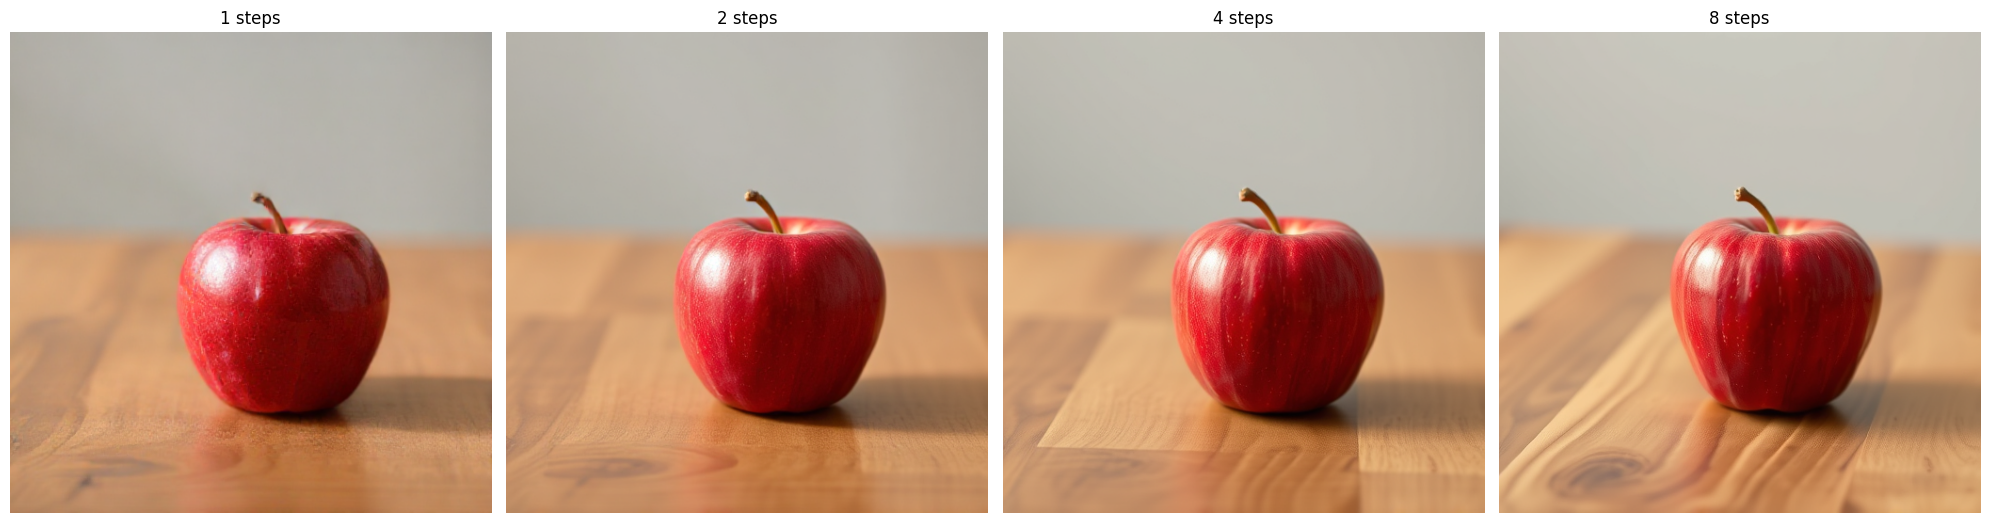

In [ ]:
prompt = "a single red apple on a wooden table, natural lighting, sharp focus"
fig, axs = plt.subplots(1, 4, figsize=(20, 6))
for ax, steps in zip(axs, [1, 2, 4, 8]):
    img = pipe(
        prompt=prompt,
        num_inference_steps=steps,
        guidance_scale=0.0,
        height=512, width=512,
        generator=torch.Generator(DEVICE).manual_seed(0),
    ).images[0]
    ax.imshow(img); ax.axis("off"); ax.set_title(f"{steps} steps")
plt.tight_layout()
plt.show()

## Takeaways

- Distillation drastically reduces sampling steps (e.g., from 50 down to 4) while maintaining quality.
- Next up: notebook 07, video generation with Wan2.1.